In [71]:
import pandas as pd
import numpy as np

df = pd.read_csv("./data/open-meteo-21.05N105.81E18m.csv", skiprows=3)

df.head()


,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),cloud_cover (%),pressure_msl (hPa),surface_pressure (hPa),wind_speed_10m (km/h),wind_direction_10m (°),shortwave_radiation (W/m²)
0,2020-01-01 00:00,19.5,93,0.4,0.4,100,1024.1,1022.0,4.6,219,0.0
1,2020-01-01 01:00,19.4,93,0.3,0.3,100,1023.9,1021.8,4.6,252,0.0
2,2020-01-01 02:00,19.2,94,0.1,0.1,100,1023.4,1021.3,4.0,270,0.0
3,2020-01-01 03:00,19.1,94,0.1,0.1,100,1023.4,1021.2,3.1,306,0.0
4,2020-01-01 04:00,18.9,94,0.1,0.1,99,1023.3,1021.1,5.4,340,0.0


In [72]:
df["time"] = pd.to_datetime(df["time"])

# Time features
df["hour"] = df["time"].dt.hour
df["dayofyear"] = df["time"].dt.dayofyear
df["month"] = df["time"].dt.month

df["season"] = df["month"].map({
    12: 0, 1: 0, 2: 0,   # winter
    3: 1, 4: 1, 5: 1,    # spring
    6: 2, 7: 2, 8: 2,    # summer
    9: 3, 10: 3, 11: 3   # autumn
})

# Lag features
df["temp_lag_1h"] = df["temperature_2m (°C)"].shift(1)
df["temp_lag_24h"] = df["temperature_2m (°C)"].shift(24)
df["humidity_lag_24h"] = df["relative_humidity_2m (%)"].shift(24)
df["precipitation_lag_1h"] = df["precipitation (mm)"].shift(1)
df["precipitation_lag_24h"] = df["precipitation (mm)"].shift(24)

# Wind direction circular encoding
wind_rad = np.deg2rad(df["wind_direction_10m (°)"])
df["wind_dir_sin"] = np.sin(wind_rad)
df["wind_dir_cos"] = np.cos(wind_rad)

# Target: predict temperature 24 hours ahead
df["target_temp"] = df["temperature_2m (°C)"].shift(-24)

df = df.dropna()


In [73]:
df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),cloud_cover (%),pressure_msl (hPa),surface_pressure (hPa),wind_speed_10m (km/h),wind_direction_10m (°),...,month,season,temp_lag_1h,temp_lag_24h,humidity_lag_24h,precipitation_lag_1h,precipitation_lag_24h,wind_dir_sin,wind_dir_cos,target_temp
24,2020-01-02 00:00:00,18.5,94,0.0,0.0,84,1023.5,1021.3,4.4,171,...,1,0,18.5,19.5,93.0,0.0,0.4,0.156434,-0.987688,19.9
25,2020-01-02 01:00:00,18.6,95,0.0,0.0,99,1023.1,1020.9,3.8,163,...,1,0,18.5,19.4,93.0,0.0,0.3,0.292372,-0.956305,20.0
26,2020-01-02 02:00:00,19.0,95,0.0,0.0,100,1022.7,1020.5,2.1,149,...,1,0,18.6,19.2,94.0,0.0,0.1,0.515038,-0.857167,20.0
27,2020-01-02 03:00:00,19.0,92,0.0,0.0,100,1022.3,1020.2,2.4,63,...,1,0,19.0,19.1,94.0,0.0,0.1,0.891007,0.453990,19.9
28,2020-01-02 04:00:00,19.0,93,0.0,0.0,99,1022.3,1020.2,3.3,77,...,1,0,19.0,18.9,94.0,0.0,0.1,0.974370,0.224951,20.0


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52560 entries, 24 to 52583
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   time                        52560 non-null  datetime64[ns]
 1   temperature_2m (°C)         52560 non-null  float64       
 2   relative_humidity_2m (%)    52560 non-null  int64         
 3   precipitation (mm)          52560 non-null  float64       
 4   rain (mm)                   52560 non-null  float64       
 5   cloud_cover (%)             52560 non-null  int64         
 6   pressure_msl (hPa)          52560 non-null  float64       
 7   surface_pressure (hPa)      52560 non-null  float64       
 8   wind_speed_10m (km/h)       52560 non-null  float64       
 9   wind_direction_10m (°)      52560 non-null  int64         
 10  shortwave_radiation (W/m²)  52560 non-null  float64       
 11  hour                        52560 non-null  int32         

In [75]:
features = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "cloud_cover (%)",
    "wind_speed_10m (km/h)",
    "pressure_msl (hPa)",
    "precipitation (mm)",

    "hour",
    "dayofyear",
    "month",
    "season",

    "temp_lag_1h",
    "temp_lag_24h",
    "humidity_lag_24h",
    "precipitation_lag_1h",
    "precipitation_lag_24h",

    "wind_dir_sin",
    "wind_dir_cos",
]

# Training
X = df[features]
y = df["target_temp"]

horizon = 24
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index - horizon]
y_train = y.iloc[:split_index - horizon]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

In [76]:
X.head()

,temperature_2m (°C),relative_humidity_2m (%),cloud_cover (%),wind_speed_10m (km/h),pressure_msl (hPa),precipitation (mm),hour,dayofyear,month,season,temp_lag_1h,temp_lag_24h,humidity_lag_24h,precipitation_lag_1h,precipitation_lag_24h,wind_dir_sin,wind_dir_cos
24,18.5,94,84,4.4,1023.5,0.0,0,2,1,0,18.5,19.5,93.0,0.0,0.4,0.156434,-0.987688
25,18.6,95,99,3.8,1023.1,0.0,1,2,1,0,18.5,19.4,93.0,0.0,0.3,0.292372,-0.956305
26,19.0,95,100,2.1,1022.7,0.0,2,2,1,0,18.6,19.2,94.0,0.0,0.1,0.515038,-0.857167
27,19.0,92,100,2.4,1022.3,0.0,3,2,1,0,19.0,19.1,94.0,0.0,0.1,0.891007,0.453990
28,19.0,93,99,3.3,1022.3,0.0,4,2,1,0,19.0,18.9,94.0,0.0,0.1,0.974370,0.224951


In [77]:
# Looking for promise model before fine-tune
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
import time

num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, features)
])

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])

    start_time = time.time()
    pipe.fit(X_train, y_train)
    training_time = time.time() - start_time

    start_time = time.time()
    y_pred = pipe.predict(X_test)
    testing_time = time.time() - start_time

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Training Time (s)": training_time,
        "Testing Time (s)": testing_time
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,Model,RMSE,MAE,R2,Training Time (s),Testing Time (s)
3,Gradient Boosting,1.768908,1.281724,0.888613,10.146565,0.022444
2,Random Forest,1.788021,1.315273,0.886193,57.295300,0.330351
0,Linear Regression,1.897640,1.361447,0.871811,0.052891,0.006958
4,KNN,2.109771,1.554764,0.841549,0.025637,0.424478
1,Decision Tree,2.461523,1.810845,0.784310,0.909447,0.012447


In [78]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
tscv = TimeSeriesSplit(n_splits=5, gap=24)


full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("gradient_boosting", GradientBoostingRegressor(random_state=42)),
])

param_distribs = {
    "gradient_boosting__n_estimators": randint(80, 250),
    "gradient_boosting__learning_rate": uniform(0.03, 0.12),
    "gradient_boosting__max_depth": randint(2, 5),
    "gradient_boosting__min_samples_leaf": randint(1, 15),
    "gradient_boosting__subsample": uniform(0.7, 0.3),
    "gradient_boosting__max_features": [None, "sqrt", 0.7, 1.0],
}

rnd_search = RandomizedSearchCV(
    full_pipeline, 
    param_distributions=param_distribs, 
    n_iter=10, 
    cv=tscv,
    scoring='neg_root_mean_squared_error', 
    random_state=42,
    n_jobs=-1
)

rnd_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'gradient_boosting__learning_rate': <scipy.stats....0020713FFD8D0>, 'gradient_boosting__max_depth': <scipy.stats....002072F47AA30>, 'gradient_boosting__max_features': [None, 'sqrt', ...], 'gradient_boosting__min_samples_leaf': <scipy.stats....0020713FC2710>, ...}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [79]:
tuned_model = rnd_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)

print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, tuned_pred)))
print("Tuned MAE:", mean_absolute_error(y_test, tuned_pred))
print("Tuned R²:", r2_score(y_test, tuned_pred))

Tuned RMSE: 1.7613245985592074
Tuned MAE: 1.2806121359682887
Tuned R²: 0.8895661798496918


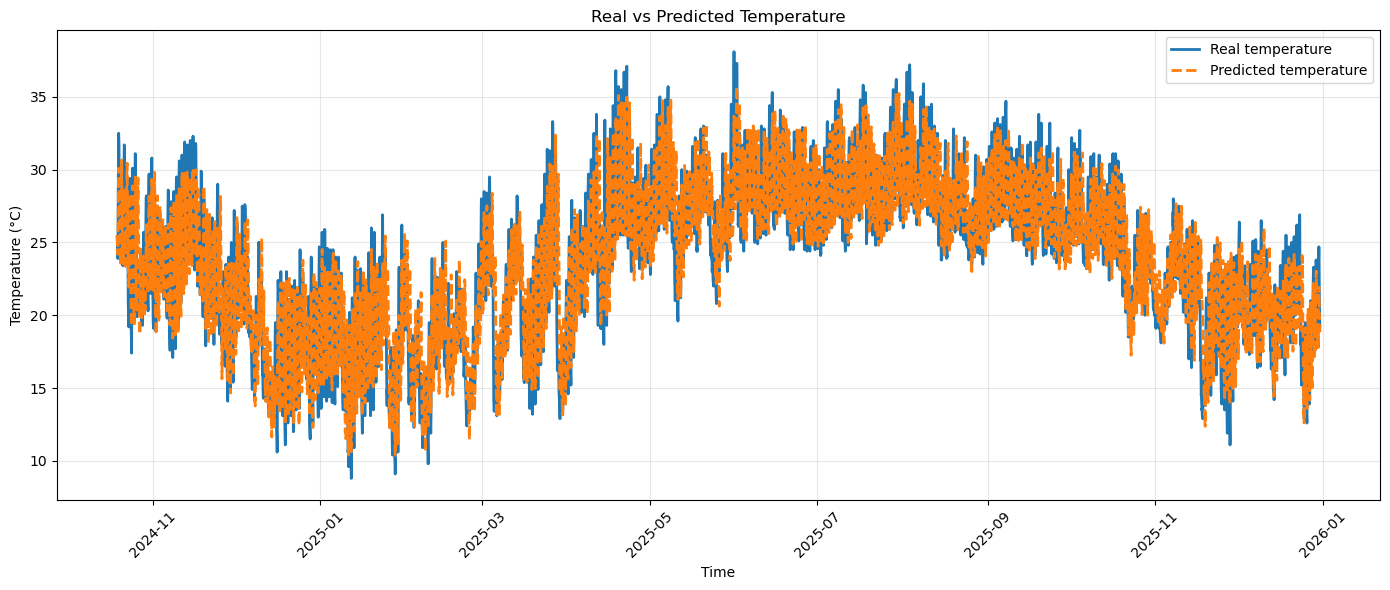

In [80]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    "time": df.loc[y_test.index, "time"],
    "real_temperature": y_test.values,
    "predicted_temperature": tuned_pred,
})

# # Plot only the first 7 days of the test set so the lines are readable.
# plot_df = comparison_df.head(24 * 7)

plt.figure(figsize=(14, 6))
plt.plot(plot_df["time"], plot_df["real_temperature"], label="Real temperature", linewidth=2)
plt.plot(plot_df["time"], plot_df["predicted_temperature"], label="Predicted temperature", linewidth=2, linestyle="--")
plt.title("Real vs Predicted Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [81]:
import matplotlib.pyplot as plt

import pandas as pd

importances = tuned_model.named_steps["gradient_boosting"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df


,feature,importance
0,temperature_2m (°C),0.534536
10,temp_lag_1h,0.266744
11,temp_lag_24h,0.123191
4,pressure_msl (hPa),0.022014
9,season,0.010400
6,hour,0.009952
7,dayofyear,0.009628
3,wind_speed_10m (km/h),0.007398
16,wind_dir_cos,0.004909
15,wind_dir_sin,0.003044


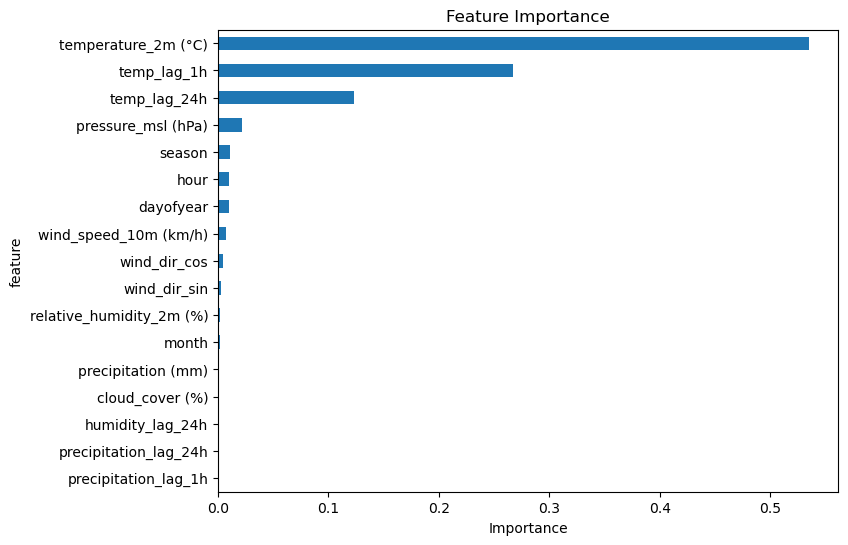

In [82]:
feature_importance_df.plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 6),
    legend=False
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [83]:
from joblib import dump, load

# Export your trained model to a file
dump(tuned_model, 'temperature_prediction_model.pkl')

['temperature_prediction_model.pkl']